In [6]:
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install geopandas
# !pip install geoalchemy2
# !pip install sqlalchemy

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
from geoalchemy2 import Geometry, WKTElement
import matplotlib.pyplot as plt
import os
import glob

In [7]:
# !pip install psycopg2
# !pip install psycopg2-binary --user
# !pip install psycopg[binary]

from sqlalchemy import create_engine
import psycopg2
import psycopg2.extras
import json

credentials = "/Users/apple/Desktop/Data2901/Credentials.json"

def pgconnect(credential_filepath, db_schema="public"):
    with open(credential_filepath) as f:
        db_conn_dict = json.load(f)
        host       = db_conn_dict['host']
        db_user    = db_conn_dict['user']
        db_pw      = db_conn_dict['password']
        default_db = db_conn_dict['user']
        port       = db_conn_dict['port']
        try:
            db = create_engine(f'postgresql+psycopg2://{db_user}:{db_pw}@{host}:{port}/{default_db}', echo=False)
            conn = db.connect()
            print('Connected successfully.')
        except Exception as e:
            print("Unable to connect to the database.")
            print(e)
            db, conn = None, None
        return db,conn

def query(conn, sqlcmd, args=None, df=True):
    result = pd.DataFrame() if df else None
    try:
        if df:
            result = pd.read_sql_query(sqlcmd, conn, params=args)
        else:
            result = conn.execute(text(sqlcmd), args).fetchall()
            result = result[0] if len(result) == 1 else result
    except Exception as e:
        print("Error encountered: ", e, sep='\n')
    return result

In [55]:
db, conn = pgconnect(credentials)

Connected successfully.


In [23]:
query(conn, "select PostGIS_Version()")

,postgis_version
0,3.4 USE_GEOS=1 USE_PROJ=1 USE_STATS=1


# 1. import all the data

In [8]:
# get all the files in csv
path = os.getcwd() 
csv_files = glob.glob(os.path.join(path, "*/*.csv")) 

print(csv_files)

# create empty list
dataframes_list = []
 
# append datasets into the list
for i in csv_files:
    temp_df = pd.read_csv(i)
    dataframes_list.append(temp_df)

df_income = dataframes_list[0]
df_pop = dataframes_list[1]
df_pol = dataframes_list[2]
df_business = dataframes_list[3]
print("Income: ",df_income.shape,'; ',df_income.columns)
print('Population: ',df_pop.shape,'; ',df_pop.columns)
print('Polling: ',df_pol.shape,'; ',df_pol.columns)
print('Business: ',df_business.shape,'; ',df_business.columns)

['/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/Income.csv', '/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/Population.csv', '/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/PollingPlaces2019.csv', '/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/Businesses.csv']
Income:  (642, 6) ;  Index(['sa2_code21', 'sa2_name', 'earners', 'median_age', 'median_income',
       'mean_income'],
      dtype='object')
Population:  (373, 21) ;  Index(['sa2_code', 'sa2_name', '0-4_people', '5-9_people', '10-14_people',
       '15-19_people', '20-24_people', '25-29_people', '30-34_people',
       '35-39_people', '40-44_people', '45-49_people', '50-54_people',
       '55-59_people', '60-64_people', '65-69_people', '70-74_people',
       '75-79_people', '80-84_people', '85-and-over_people', 'total_people'],
      dtype='object')
Polling:  (2930, 17) ;  Index(['FID', 'state', 'division_id', 'division_name', 'polling_place_id',
       'polling_pl

In [9]:
df_income.head()

,sa2_code21,sa2_name,earners,median_age,median_income,mean_income
0,101021007,Braidwood,2467,51,46640,68904
1,101021008,Karabar,5103,42,65564,69672
2,101021009,Queanbeyan,7028,39,63528,69174
3,101021010,Queanbeyan - East,3398,39,66148,74162
4,101021012,Queanbeyan West - Jerrabomberra,8422,44,78630,91981


In [10]:
df_pop.head()

,sa2_code,sa2_name,0-4_people,5-9_people,10-14_people,15-19_people,20-24_people,25-29_people,30-34_people,35-39_people,...,45-49_people,50-54_people,55-59_people,60-64_people,65-69_people,70-74_people,75-79_people,80-84_people,85-and-over_people,total_people
0,102011028,Avoca Beach - Copacabana,424,522,623,552,386,222,306,416,...,572,602,570,520,464,369,226,142,70,7530
1,102011029,Box Head - MacMasters Beach,511,666,702,592,461,347,420,535,...,749,749,794,895,863,925,603,331,264,11052
2,102011030,Calga - Kulnura,200,225,258,278,274,227,214,286,...,325,436,422,397,327,264,190,100,75,4748
3,102011031,Erina - Green Point,683,804,880,838,661,502,587,757,...,859,882,901,930,917,1065,976,773,1028,14803
4,102011032,Gosford - Springfield,1164,1044,1084,1072,1499,1864,1750,1520,...,1330,1241,1377,1285,1166,949,664,476,537,21346


In [11]:
df_pol.head()

,FID,state,division_id,division_name,polling_place_id,polling_place_type_id,polling_place_name,premises_name,premises_address_1,premises_address_2,premises_address_3,premises_suburb,premises_state_abbreviation,premises_post_code,latitude,longitude,the_geom
0,aec_federal_election_polling_places_2019.fid-4...,NSW,104,Barton,33595,2,Special Hospital Team 1,Multiple sites,NaN,NaN,NaN,NaN,NSW,NaN,NaN,NaN,NaN
1,aec_federal_election_polling_places_2019.fid-4...,NSW,105,Bennelong,33596,2,Special Hospital Team 1,Multiple sites,NaN,NaN,NaN,NaN,NSW,NaN,NaN,NaN,NaN
2,aec_federal_election_polling_places_2019.fid-4...,NSW,107,Blaxland,33600,2,Special Hospital Team 1,Multiple sites,NaN,NaN,NaN,NaN,NSW,NaN,NaN,NaN,NaN
3,aec_federal_election_polling_places_2019.fid-4...,NSW,109,Calare,33603,2,Special Hospital Team 1,Multiple sites,NaN,NaN,NaN,ORANGE,NSW,2800.0,NaN,NaN,NaN
4,aec_federal_election_polling_places_2019.fid-4...,NSW,113,Cowper,33716,2,Special Hospital Team 2,Multiple sites,NaN,NaN,NaN,NaN,NSW,NaN,NaN,NaN,NaN


In [12]:
df_business.head()

,industry_code,industry_name,sa2_code,sa2_name,0_to_50k_businesses,50k_to_200k_businesses,200k_to_2m_businesses,2m_to_5m_businesses,5m_to_10m_businesses,10m_or_more_businesses,total_businesses
0,A,"Agriculture, Forestry and Fishing",101021007,Braidwood,136,92,63,4,0,0,296
1,A,"Agriculture, Forestry and Fishing",101021008,Karabar,6,3,0,0,0,0,9
2,A,"Agriculture, Forestry and Fishing",101021009,Queanbeyan,6,4,3,0,0,3,15
3,A,"Agriculture, Forestry and Fishing",101021010,Queanbeyan - East,0,3,0,0,0,0,3
4,A,"Agriculture, Forestry and Fishing",101021012,Queanbeyan West - Jerrabomberra,7,4,5,0,0,0,16


## import txt files

In [13]:
# import txt file
# path = os.getcwd() 
txt_files = glob.glob(os.path.join(path, "*/*.txt")) 

df_stops = pd.read_csv(i)
print(df_stops.shape)
print(df_stops.columns)

(12217, 11)
Index(['industry_code', 'industry_name', 'sa2_code', 'sa2_name',
       '0_to_50k_businesses', '50k_to_200k_businesses',
       '200k_to_2m_businesses', '2m_to_5m_businesses', '5m_to_10m_businesses',
       '10m_or_more_businesses', 'total_businesses'],
      dtype='object')


## read the shp file from catchments

In [19]:
# get the shp files
print(path)
shp_files = glob.glob(os.path.join(path, "*/*/*.shp")) 

# create empty list
dataframes_list_shp = []
 
# append datasets into the list
for i in shp_files:
    temp_df = gpd.read_file(i)
    dataframes_list_shp.append(temp_df)

df_catch_f = dataframes_list_shp[0]
df_catch_s = dataframes_list_shp[1]
df_catch_p = dataframes_list_shp[2]
print("catchment future: ",df_catch_f.shape,'; ',df_catch_f.columns)
print('catchment secondary: ',df_catch_s.shape,'; ',df_catch_s.columns)
print('catchment primary: ',df_catch_p.shape,'; ',df_catch_p.columns)

df_catch_f.head()

/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1
catchment future:  (436, 19) ;  Index(['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', 'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9',
       'YEAR10', 'YEAR11', 'YEAR12', 'PRIORITY', 'geometry'],
      dtype='object')
catchment secondary:  (30, 18) ;  Index(['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', 'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9',
       'YEAR10', 'YEAR11', 'YEAR12', 'geometry'],
      dtype='object')
catchment primary:  (1662, 19) ;  Index(['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', 'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9',
       'YEAR10', 'YEAR11', 'YEAR12', 'PRIORITY', 'geometry'],
      dtype='object')


,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geometry
0,8503,HIGH_COED,Billabong HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((146.67182 -35.31444, 146.68930 -35.3..."
1,8266,HIGH_COED,James Fallon HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((147.08734 -35.86271, 147.10413 -35.8..."
2,8505,HIGH_COED,Murray HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((146.81448 -35.78341, 146.81250 -35.7..."
3,8458,HIGH_COED,Kingswood HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"MULTIPOLYGON (((150.68600 -33.74031, 150.68631..."
4,8559,HIGH_COED,Jamison HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,"POLYGON ((150.69513 -33.75627, 150.68936 -33.7..."


In [20]:
df_catch_s['PRIORITY'] = 'None'
df_catch_s1 = df_catch_s[['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', 'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9',
       'YEAR10', 'YEAR11', 'YEAR12', 'PRIORITY', 'geometry']]

In [21]:
dataframes_list_shp

[    USE_ID    CATCH_TYPE         USE_DESC  ADD_DATE KINDERGART YEAR1 YEAR2  \
 0     8503     HIGH_COED     Billabong HS  20200507          N     N     N   
 1     8266     HIGH_COED  James Fallon HS  20200507          N     N     N   
 2     8505     HIGH_COED        Murray HS  20200507          N     N     N   
 3     8458     HIGH_COED     Kingswood HS  20201016          N     N     N   
 4     8559     HIGH_COED       Jamison HS  20201016          N     N     N   
 ..     ...           ...              ...       ...        ...   ...   ...   
 431   8213     HIGH_BOYS      Birrong BHS  20211221          N     N     N   
 432   8108     HIGH_COED      Cessnock HS  20230405          N     N     N   
 433   3235  CENTRAL_HIGH     Tooleybuc CS  20200512          N     N     N   
 434   1115  CENTRAL_HIGH     Balranald CS  20200512          N     N     N   
 435   2213  CENTRAL_HIGH       Ivanhoe CS  20200512          N     N     N   
 
     YEAR3 YEAR4 YEAR5 YEAR6 YEAR7 YEAR8 YEAR9 YEA

In [25]:
df_school = pd.concat([df_catch_f, df_catch_s1,df_catch_p])
print(df_school.shape)
df_school.tail()

(2128, 19)


,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geometry
1657,4383,PRIMARY,E A Southee PS,20200315,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((147.94621 -34.55863, 147.95292 -34.5..."
1658,3275,PRIMARY,Tumbarumba PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((148.12885 -35.60082, 148.23155 -35.6..."
1659,2239,PRIMARY,Jindera PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((146.86148 -35.87511, 146.87402 -35.8..."
1660,3594,PRIMARY,Louth PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((145.18403 -29.65805, 145.18434 -29.6..."
1661,2155,PRIMARY,Hermidale PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,"POLYGON ((146.46001 -31.31688, 146.47453 -31.3..."


In [28]:
#transform to multipolygon
srid = 4326

def create_wkt_element(geom, srid):
    if geom.geom_type == 'Polygon':
        geom = MultiPolygon([geom])
    return WKTElement(geom.wkt, srid)

df_schoolog = df_school.copy()  # creating a copy of the original for laterog = df_school.copy()  # creating a copy of the original for later
df_school['geom'] = df_school['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=srid))  # applying the function
df_school = df_school.drop(columns="geometry")  # deleting the old copy
df_school

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geom
0,8503,HIGH_COED,Billabong HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((146.67182402032344 -35.3144375...
1,8266,HIGH_COED,James Fallon HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((147.08733806259178 -35.8627146...
2,8505,HIGH_COED,Murray HS,20200507,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((146.81447829547324 -35.7834062...
3,8458,HIGH_COED,Kingswood HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((150.68599834118749 -33.7403060...
4,8559,HIGH_COED,Jamison HS,20201016,N,N,N,N,N,N,N,Y,Y,Y,Y,Y,Y,None,MULTIPOLYGON (((150.69513440644116 -33.7562688...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657,4383,PRIMARY,E A Southee PS,20200315,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((147.9462089946497 -34.55863148...
1658,3275,PRIMARY,Tumbarumba PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((148.12885348977485 -35.6008184...
1659,2239,PRIMARY,Jindera PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((146.86147943204122 -35.8751106...
1660,3594,PRIMARY,Louth PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((145.18402754685187 -29.6580498...


In [87]:
# check if multipolygon, need to fix
import shapely
df_school.loc[df_school["geom"].apply(lambda x: type(x) == shapely.geometry.multipolygon.point)]

AttributeError: module 'shapely.geometry.multipolygon' has no attribute 'point'

# 2. data validations

In [31]:
## check data types, nulls, duplicates, unique values
df_school.dtypes

USE_ID        object
CATCH_TYPE    object
USE_DESC      object
ADD_DATE      object
KINDERGART    object
YEAR1         object
YEAR2         object
YEAR3         object
YEAR4         object
YEAR5         object
YEAR6         object
YEAR7         object
YEAR8         object
YEAR9         object
YEAR10        object
YEAR11        object
YEAR12        object
PRIORITY      object
geom          object
dtype: object

In [37]:
print(df_school.shape)
print(df_school.drop_duplicates().shape)

print(df_business.shape)
print(df_business.drop_duplicates().shape)

print(df_income.shape)
print(df_income.drop_duplicates().shape)

print(df_pol.shape)
print(df_pol.drop_duplicates().shape)

print(df_pop.shape)
print(df_pop.drop_duplicates().shape)
# no duplicated rows

(2128, 19)
(2128, 19)
(12217, 11)
(12217, 11)
(642, 6)
(642, 6)
(2930, 17)
(2930, 17)
(373, 21)
(373, 21)


In [43]:
print(df_school.isna().sum())
df_school.nunique()

USE_ID           0
CATCH_TYPE       0
USE_DESC         0
ADD_DATE       391
KINDERGART       0
YEAR1            0
YEAR2            0
YEAR3            0
YEAR4            0
YEAR5            0
YEAR6            0
YEAR7            0
YEAR8            0
YEAR9            0
YEAR10           0
YEAR11           0
YEAR12           0
PRIORITY      2087
geom             0
dtype: int64


USE_ID        2035
CATCH_TYPE       7
USE_DESC      2035
ADD_DATE       209
KINDERGART       4
YEAR1            4
YEAR2            4
YEAR3            4
YEAR4            4
YEAR5            4
YEAR6            4
YEAR7            4
YEAR8            4
YEAR9            4
YEAR10           5
YEAR11           5
YEAR12           6
PRIORITY         3
geom          2084
dtype: int64

In [49]:
print(df_business.dtypes)
print(df_business.isna().sum())
df_business.nunique()

industry_code             object
industry_name             object
sa2_code                   int64
sa2_name                  object
0_to_50k_businesses        int64
50k_to_200k_businesses     int64
200k_to_2m_businesses      int64
2m_to_5m_businesses        int64
5m_to_10m_businesses       int64
10m_or_more_businesses     int64
total_businesses           int64
dtype: object
industry_code             0
industry_name             0
sa2_code                  0
sa2_name                  0
0_to_50k_businesses       0
50k_to_200k_businesses    0
200k_to_2m_businesses     0
2m_to_5m_businesses       0
5m_to_10m_businesses      0
10m_or_more_businesses    0
total_businesses          0
dtype: int64


industry_code              19
industry_name              19
sa2_code                  643
sa2_name                  643
0_to_50k_businesses       249
50k_to_200k_businesses    260
200k_to_2m_businesses     269
2m_to_5m_businesses        79
5m_to_10m_businesses       44
10m_or_more_businesses     67
total_businesses          561
dtype: int64

In [50]:
print(df_pol.dtypes)
print(df_pol.isna().sum())
df_pol.nunique()

FID                             object
state                           object
division_id                      int64
division_name                   object
polling_place_id                 int64
polling_place_type_id            int64
polling_place_name              object
premises_name                   object
premises_address_1              object
premises_address_2              object
premises_address_3              object
premises_suburb                 object
premises_state_abbreviation     object
premises_post_code             float64
latitude                       float64
longitude                      float64
the_geom                        object
dtype: object
FID                               0
state                             0
division_id                       0
division_name                     0
polling_place_id                  0
polling_place_type_id             0
polling_place_name                0
premises_name                     0
premises_address_1              193

FID                            2930
state                             1
division_id                      47
division_name                    47
polling_place_id               2930
polling_place_type_id             4
polling_place_name             2757
premises_name                  2463
premises_address_1             2408
premises_address_2               46
premises_address_3                7
premises_suburb                1522
premises_state_abbreviation       3
premises_post_code              593
latitude                       2498
longitude                      2242
the_geom                       2543
dtype: int64

In [46]:
print(df_pop.isna().sum())
df_pop.nunique()

sa2_code              0
sa2_name              0
0-4_people            0
5-9_people            0
10-14_people          0
15-19_people          0
20-24_people          0
25-29_people          0
30-34_people          0
35-39_people          0
40-44_people          0
45-49_people          0
50-54_people          0
55-59_people          0
60-64_people          0
65-69_people          0
70-74_people          0
75-79_people          0
80-84_people          0
85-and-over_people    0
total_people          0
dtype: int64


sa2_code              373
sa2_name              373
0-4_people            324
5-9_people            327
10-14_people          332
15-19_people          318
20-24_people          324
25-29_people          340
30-34_people          336
35-39_people          331
40-44_people          328
45-49_people          326
50-54_people          326
55-59_people          317
60-64_people          314
65-69_people          304
70-74_people          302
75-79_people          286
80-84_people          258
85-and-over_people    272
total_people          365
dtype: int64

In [ ]:
print(df_business.dtypes)
print(df_business.isna().sum())
df_business.nunique()

industry_code             object
industry_name             object
sa2_code                   int64
sa2_name                  object
0_to_50k_businesses        int64
50k_to_200k_businesses     int64
200k_to_2m_businesses      int64
2m_to_5m_businesses        int64
5m_to_10m_businesses       int64
10m_or_more_businesses     int64
total_businesses           int64
dtype: object
industry_code             0
industry_name             0
sa2_code                  0
sa2_name                  0
0_to_50k_businesses       0
50k_to_200k_businesses    0
200k_to_2m_businesses     0
2m_to_5m_businesses       0
5m_to_10m_businesses      0
10m_or_more_businesses    0
total_businesses          0
dtype: int64


industry_code              19
industry_name              19
sa2_code                  643
sa2_name                  643
0_to_50k_businesses       249
50k_to_200k_businesses    260
200k_to_2m_businesses     269
2m_to_5m_businesses        79
5m_to_10m_businesses       44
10m_or_more_businesses     67
total_businesses          561
dtype: int64

In [51]:
print(df_income.dtypes)
print(df_income.isna().sum())
df_income.nunique()

sa2_code21        int64
sa2_name         object
earners          object
median_age       object
median_income    object
mean_income      object
dtype: object
sa2_code21       0
sa2_name         0
earners          0
median_age       0
median_income    0
mean_income      0
dtype: int64


sa2_code21       642
sa2_name         642
earners          623
median_age        29
median_income    635
mean_income      631
dtype: int64

# 3. import into sql 

In [89]:
conn.execute("""
DROP TABLE IF EXISTS polls;
CREATE TABLE polls (
    FID                             varchar(100),
state                           varchar(100),
division_id                      integer,
division_name                   varchar(100),
polling_place_id                 integer,
polling_place_type_id            integer,
polling_place_name              varchar(100),
premises_name                   varchar(100),
premises_address_1              varchar(100),
premises_address_2              varchar(100),
premises_address_3              varchar(100),
premises_suburb                 varchar(100),
premises_state_abbreviation     varchar(100),
premises_post_code             integer,
latitude                       float,
longitude                      float,
the_geom                       GEOMETRY(POINT,4326)
);"""
)
df_pol.to_sql('polls', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from polls")

conn.execute("""
DROP TABLE IF EXISTS populations;
CREATE TABLE populations (
    pop_est NUMERIC, 
    continent VARCHAR(80), 
    name VARCHAR(80), 
    iso_a3 VARCHAR(80), 
    gdp_md_est NUMERIC,
    geom GEOMETRY(MULTIPOLYGON,4326)
);"""
)
df_pop.to_sql('populations', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from populations")

conn.execute("""
DROP TABLE IF EXISTS incomes;
CREATE TABLE incomes (
    sa2_code21        integer,
sa2_name         varchar(100),
earners          varchar(100),
median_age       varchar(100),
median_income    varchar(100),
mean_income      varchar(100)
);"""
)
df_income.to_sql('incomes', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from incomes")

conn.execute("""
DROP TABLE IF EXISTS schools;
CREATE TABLE schools (
USE_ID        integer,
CATCH_TYPE    varchar(100),
USE_DESC      varchar(100),
ADD_DATE      date,
KINDERGART    varchar(100),
YEAR1         varchar(100),
YEAR2         varchar(100),
YEAR3         varchar(100),
YEAR4         varchar(100),
YEAR5         varchar(100),
YEAR6         varchar(100),
YEAR7         varchar(100),
YEAR8         varchar(100),
YEAR9         varchar(100),
YEAR10        varchar(100),
YEAR11        varchar(100),
YEAR12        varchar(100),
PRIORITY      varchar(100),
    geom GEOMETRY(MULTIPOLYGON,4326)
);"""
)
df_school.to_sql('schools', conn, if_exists='replace', index=False, dtype={'geom': Geometry('MULTIPOLYGON', srid)})
query(conn, "select * from schools")

conn.execute("""
DROP TABLE IF EXISTS business;
CREATE TABLE business (
    industry_code             varchar(100),
    industry_name             varchar(100),
    sa2_code                   integer,
    sa2_name                  varchar(100),
    "0_to_50k_businesses"       integer,
    "50k_to_200k_businesses"     integer,
    "200k_to_2m_businesses"      integer,
    "2m_to_5m_businesses"        integer,
    "5m_to_10m_businesses"       integer,
    "10m_or_more_businesses"     integer,
    total_businesses           integer
);"""
)
df_business.to_sql('business', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from business")


,industry_code,industry_name,sa2_code,sa2_name,0_to_50k_businesses,50k_to_200k_businesses,200k_to_2m_businesses,2m_to_5m_businesses,5m_to_10m_businesses,10m_or_more_businesses,total_businesses
0,A,"Agriculture, Forestry and Fishing",101021007,Braidwood,136,92,63,4,0,0,296
1,A,"Agriculture, Forestry and Fishing",101021008,Karabar,6,3,0,0,0,0,9
2,A,"Agriculture, Forestry and Fishing",101021009,Queanbeyan,6,4,3,0,0,3,15
3,A,"Agriculture, Forestry and Fishing",101021010,Queanbeyan - East,0,3,0,0,0,0,3
4,A,"Agriculture, Forestry and Fishing",101021012,Queanbeyan West - Jerrabomberra,7,4,5,0,0,0,16
...,...,...,...,...,...,...,...,...,...,...,...
12212,S,Other Services,128021538,Sutherland - Kirrawee,21,66,58,3,3,0,152
12213,S,Other Services,128021607,Engadine,13,41,31,3,0,0,87
12214,S,Other Services,128021608,Loftus - Yarrawarrah,0,10,10,0,0,0,22
12215,S,Other Services,128021609,Woronora Heights,0,3,5,0,0,0,9


In [53]:
df_business

,industry_code,industry_name,sa2_code,sa2_name,0_to_50k_businesses,50k_to_200k_businesses,200k_to_2m_businesses,2m_to_5m_businesses,5m_to_10m_businesses,10m_or_more_businesses,total_businesses
0,A,"Agriculture, Forestry and Fishing",101021007,Braidwood,136,92,63,4,0,0,296
1,A,"Agriculture, Forestry and Fishing",101021008,Karabar,6,3,0,0,0,0,9
2,A,"Agriculture, Forestry and Fishing",101021009,Queanbeyan,6,4,3,0,0,3,15
3,A,"Agriculture, Forestry and Fishing",101021010,Queanbeyan - East,0,3,0,0,0,0,3
4,A,"Agriculture, Forestry and Fishing",101021012,Queanbeyan West - Jerrabomberra,7,4,5,0,0,0,16
...,...,...,...,...,...,...,...,...,...,...,...
12212,S,Other Services,128021538,Sutherland - Kirrawee,21,66,58,3,3,0,152
12213,S,Other Services,128021607,Engadine,13,41,31,3,0,0,87
12214,S,Other Services,128021608,Loftus - Yarrawarrah,0,10,10,0,0,0,22
12215,S,Other Services,128021609,Woronora Heights,0,3,5,0,0,0,9


# plot

<AxesSubplot:>

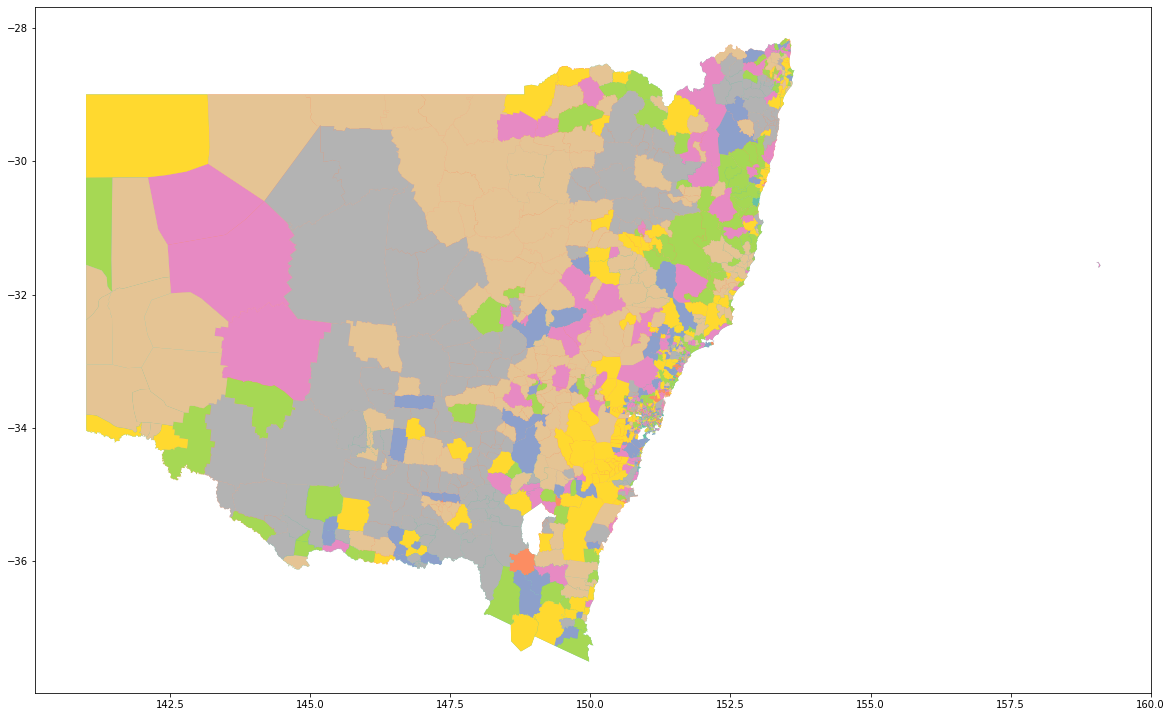

In [98]:
schools = gpd.read_postgis('''select "USE_DESC",geom from schools''', conn, crs=4326)
schools.plot(figsize=(20, 20),cmap='Set2')